# Step 15: The Gatekeeper Showdown (Final Comparison)

## 🎯 Objective:
Membandingkan efektivitas berbagai jenis "Gatekeeper" untuk menentukan mana yang memberikan performa terbaik bagi protofolio Markowitz:
1. **Baseline**: Strategi Markowitz tanpa filter (Selalu Investasi).
2. **Reactive Gate (Volatility)**: Berdasarkan data historis volatilitas berjalan (Tanpa AI).
3. **Topological Gate (Graph Density)**: Berdasarkan kepadatan hubungan antar aset (Step 10).
4. **Predictive AI Gate (PCA+XGB)**: Berdasarkan ramalan AI untuk hari esok (Step 14).

## 💡 Strategy Logic:
- **Risk-On**: Alokasi dana menggunakan Markowitz Mean-Variance Optimization pada 24 aset crypto.
- **Risk-Off**: Memindahkan 100% dana ke **PAX Gold (PAXG)** sebagai aset pelindung (Safe Haven).

## 📊 Metrics:
- Cumulative Returns
- Sharpe Ratio
- Maximum Drawdown (MDD)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Final Showdown Environment Ready!")

✅ Final Showdown Environment Ready!


## 1. Data Preparation & Robust Cleaning

In [4]:
# Load Dataset
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)

# Robust Cleaning
returns = df.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)

# Pisahkan Aset Investasi (Crypto) dan Aset Pelindung (PAXG)
crypto_assets = [c for c in df.columns if c != 'PAXG-USD']
paxg_ret = returns['PAXG-USD']
crypto_rets = returns[crypto_assets]

# --- 1. Calculated Signals (Reactive) ---
# Volatility Signal (High Vol = Bearish)
vol_signal = crypto_rets['BTC-USD'].rolling(20).std() > crypto_rets['BTC-USD'].rolling(60).std()

# Graph Density Signal (Corrected implementation)
def calculate_graph_density_series(ret_df, window=20, threshold=0.5):
    print("🔄 Calculating rolling graph density...")
    rolling_corr = ret_df.rolling(window).corr()
    densities = []
    dates = []
    v = len(ret_df.columns)
    max_edges = v * (v - 1) / 2
    
    valid_dates = ret_df.index[window-1:]
    for date in valid_dates:
        corr_matrix = rolling_corr.loc[date].fillna(0)
        adj_matrix = (corr_matrix > threshold).astype(int)
        edges = (adj_matrix.values.sum() - v) / 2
        densities.append(edges / max_edges if max_edges > 0 else 0)
        dates.append(date)
    return pd.Series(densities, index=dates)

density_series = calculate_graph_density_series(crypto_rets)
graph_signal = density_series > 0.4 

# --- 2. AI Predictive Signal (PCA+XGB) ---
scaler = StandardScaler()
pca = PCA(n_components=5)
factors = pca.fit_transform(scaler.fit_transform(crypto_rets))
X_pca = pd.DataFrame(factors, index=crypto_rets.index, columns=[f'PC{i+1}' for i in range(5)])

# Target
y_target = np.where(crypto_rets['BTC-USD'].shift(-1) > 0.005, 1, 0)
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Train on 2023-2024, Predict 2025
train_idx = X_pca.index.year < 2025
model.fit(X_pca[train_idx], y_target[train_idx])
ai_predictions = pd.Series(model.predict(X_pca), index=X_pca.index)

print("✅ Signals Calculated.")

🔄 Calculating rolling graph density...
✅ Signals Calculated.


## 2. Portfolio Optimization Core (Markowitz)

In [5]:
def get_markowitz_weights(rets):
    n = len(rets.columns)
    mu = rets.mean()
    sigma = rets.cov()
    
    def obj(w):
        ret = w.T @ mu
        vol = np.sqrt(w.T @ sigma @ w)
        return - (ret / vol) if vol > 1e-6 else 0
    
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = [(0, 0.2) for _ in range(n)] 
    
    res = minimize(obj, [1.0/n]*n, bounds=bounds, constraints=cons)
    return res.x

print("✅ Markowitz Optimizer Ready.")

✅ Markowitz Optimizer Ready.


## 3. Backtesting (The Showdown)

In [6]:
test_period = returns.index.year == 2025
test_df = returns[test_period]
results = pd.DataFrame(index=test_df.index)

# 1. Baseline: Markowitz Only
train_rets = crypto_rets[crypto_rets.index.year < 2025]
w_baseline = get_markowitz_weights(train_rets)
results['Baseline_Markowitz'] = (test_df[crypto_assets] @ w_baseline)

# Reindex signals
v_sig = vol_signal.reindex(test_df.index, fill_value=False)
g_sig = graph_signal.reindex(test_df.index, fill_value=False)
a_pred = ai_predictions.reindex(test_df.index, fill_value=1)

# 2. Reactive Gate (Volatility)
results['Reactive_Vol_Gate'] = np.where(v_sig, paxg_ret.loc[test_df.index], results['Baseline_Markowitz'])

# 3. Topological Gate (Graph Density)
results['Topological_Gate'] = np.where(g_sig, paxg_ret.loc[test_df.index], results['Baseline_Markowitz'])

# 4. AI Predictive Gate
results['AI_Gated_Markowitz'] = np.where(a_pred == 0, paxg_ret.loc[test_df.index], results['Baseline_Markowitz'])

print("✅ Backtest completed.")

✅ Backtest completed.


## 4. Final Comparison & Metrics

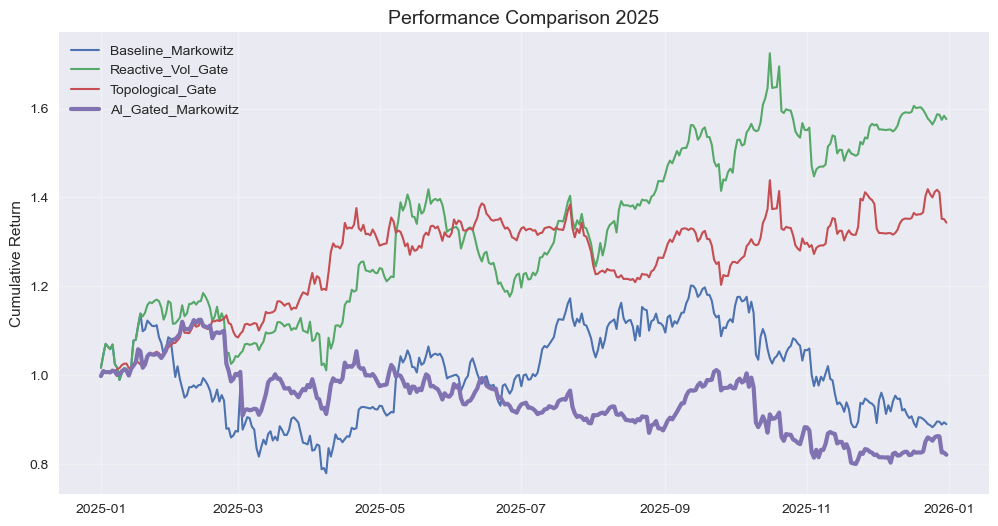


--- FINAL PERFORMANCE SUMMARY ---
                    Return (%)  Sharpe Ratio  Max Drawdown (%)
Reactive_Vol_Gate    57.631233      1.331721        -17.016888
Topological_Gate     34.346296      1.176653        -13.208027
Baseline_Markowitz  -10.966147     -0.062930        -31.523446
AI_Gated_Markowitz  -17.848332     -0.446891        -28.841493


In [7]:
cumulative = (1 + results).cumprod()

plt.figure(figsize=(12, 6))
for col in cumulative.columns:
    lw = 3 if "AI" in col else 1.5
    plt.plot(cumulative[col], label=col, lw=lw)

plt.title('Performance Comparison 2025', fontsize=14)
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

summary = pd.DataFrame({
    'Return (%)': (cumulative.iloc[-1] - 1) * 100,
    'Sharpe Ratio': results.mean() / results.std() * np.sqrt(252),
    'Max Drawdown (%)': (cumulative / cumulative.cummax() - 1).min() * 100
})

print("\n--- FINAL PERFORMANCE SUMMARY ---")
print(summary.sort_values('Sharpe Ratio', ascending=False))